# Cardiac Patient Monitoring System

## Project Overview

This project analyzes a cardiovascular disease dataset using statistical analysis,
exploratory data analysis, supervised machine learning, feature engineering,
pipelines, and unsupervised learning.

The main objective is to explore patient-related features and build machine
learning models to classify whether cardiovascular disease is present.



In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [248]:
df = pd.read_csv("cardio.csv", sep=";")

In [249]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [250]:
df.shape

(70000, 13)

In [251]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [252]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [253]:
df.duplicated().sum()

np.int64(0)

In [254]:
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [255]:
df["cardio"].value_counts(normalize=True).mul(100).round(2)

cardio
0    50.03
1    49.97
Name: proportion, dtype: float64

### Cardio Analysis
The target variable is cardio, which represents the presence or absence
of cardiovascular disease.

- 0 → No cardiovascular disease
- 1 → Cardiovascular disease

In [256]:
df["age"].describe()

count    70000.000000
mean     19468.865814
std       2467.251667
min      10798.000000
25%      17664.000000
50%      19703.000000
75%      21327.000000
max      23713.000000
Name: age, dtype: float64

In [257]:
(df["age"] / 365.25).describe()

count    70000.000000
mean        53.302850
std          6.754967
min         29.563313
25%         48.361396
50%         53.943874
75%         58.390144
max         64.922656
Name: age, dtype: float64

### Age Analysis
The age feature is stored in days. The observed values correspond
approximately to ages between 30 and 65 years. No negative age values
were found.

In [258]:
df["gender"].describe()

count    70000.000000
mean         1.349571
std          0.476838
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: gender, dtype: float64

In [259]:
df["gender"].unique()

array([2, 1])

### Gender Analysis
The gender feature contains two encoded categories (1 and 2).
No unexpected gender categories were found.encoded as 1 = Female and 2 = Male

In [260]:
df["height"].describe()


count    70000.000000
mean       164.359229
std          8.210126
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

In [261]:
Q1_height = df["height"].quantile(0.25)
Q3_height = df["height"].quantile(0.75)

IQR_height = Q3_height - Q1_height

lower_height = Q1_height - 1.5 * IQR_height
upper_height = Q3_height + 1.5 * IQR_height

print("Q1:", Q1_height)
print("Q3:", Q3_height)
print("IQR:", IQR_height)
print("Lower Bound:", lower_height)
print("Upper Bound:", upper_height)

Q1: 159.0
Q3: 170.0
IQR: 11.0
Lower Bound: 142.5
Upper Bound: 186.5


In [262]:
height_outliers = (
    (df["height"] < lower_height) |
    (df["height"] > upper_height)
)

print("Number of height outliers:", height_outliers.sum())
print("Percentage:", round(height_outliers.mean() * 100, 2), "%")

Number of height outliers: 519
Percentage: 0.74 %


In [263]:
df.loc[height_outliers, "height"].value_counts().sort_index()

height
55      1
57      1
59      1
60      1
64      1
       ..
197     4
198    14
200     1
207     1
250     1
Name: count, Length: 65, dtype: int64

In [264]:
df.loc[df["height"] < 100, "height"].value_counts().sort_index()

height
55    1
57    1
59    1
60    1
64    1
65    2
66    1
67    3
68    2
70    3
71    1
72    1
74    1
75    2
76    1
80    1
81    1
91    1
96    1
97    1
98    1
99    1
Name: count, dtype: int64

### Height Analysis

The height feature ranges from 55 cm to 250 cm, with a mean of
approximately 164.36 cm.

The IQR method identified 519 observations (0.74%) as statistical
outliers. Additionally, 29 observations have a height below 100 cm.

In [265]:
df["weight"].describe()

count    70000.000000
mean        74.205690
std         14.395757
min         10.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

In [266]:
print("Weight <= 0:", (df["weight"] <= 0).sum())

Weight <= 0: 0


In [267]:
Q1_weight = df["weight"].quantile(0.25)
Q3_weight = df["weight"].quantile(0.75)

IQR_weight = Q3_weight - Q1_weight

lower_weight = Q1_weight - 1.5 * IQR_weight
upper_weight = Q3_weight + 1.5 * IQR_weight

print("Q1:", Q1_weight)
print("Q3:", Q3_weight)
print("IQR:", IQR_weight)
print("Lower Bound:", lower_weight)
print("Upper Bound:", upper_weight)

Q1: 65.0
Q3: 82.0
IQR: 17.0
Lower Bound: 39.5
Upper Bound: 107.5


In [268]:
weight_outliers = (
    (df["weight"] < lower_weight) |
    (df["weight"] > upper_weight)
)

print("Number of weight outliers:", weight_outliers.sum())
print("Percentage:", round(weight_outliers.mean() * 100, 2), "%")

Number of weight outliers: 1819
Percentage: 2.6 %


In [269]:
df.loc[weight_outliers, "weight"].value_counts().sort_index()

weight
10.0     1
11.0     1
21.0     1
22.0     1
23.0     1
        ..
178.0    3
180.0    4
181.0    1
183.0    1
200.0    2
Name: count, Length: 93, dtype: int64

### Weight Analysis

The weight feature ranges from 10 kg to 200 kg, with a mean of
approximately 74.21 kg.

Using the IQR method, 1,819 observations (2.60%) were identified as
statistical outliers. The identified values range from very low weights
such as 10 kg to high values such as 200 kg.

In [270]:
df["cholesterol"].value_counts().sort_index()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

In [271]:
invalid_cholesterol = ~df["cholesterol"].isin([1, 2, 3])

print("Invalid cholesterol values:", invalid_cholesterol.sum())

Invalid cholesterol values: 0


### Cholesterol Analysis
The cholesterol feature represents the patient's cholesterol level.
It contains three ordinal categories:

- 1 : Normal
- 2 : Above normal
- 3 : Well above normal
  
The feature contains only the expected values (1, 2, and 3), with no invalid
categories detected.

In [272]:
df["gluc"].value_counts().sort_index()

gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

In [273]:
invalid_gluc = ~df["gluc"].isin([1, 2, 3])

print("Invalid glucose values:", invalid_gluc.sum())

Invalid glucose values: 0


### Glucose Analysis
The gluc feature represents the patient's glucose level.
It contains three ordinal categories:

- 1 : Normal
- 2 : Above normal
- 3 :  Well above normal

The feature contains only the expected values (1, 2, and 3), with no invalid
categories detected.

In [274]:
df["smoke"].value_counts().sort_index()

smoke
0    63831
1     6169
Name: count, dtype: int64

In [275]:
invalid_smoke = ~df["smoke"].isin([0, 1])

print("Invalid smoking values:", invalid_smoke.sum())

Invalid smoking values: 0


### Smoking Analysis

The smoke feature represents the patient's smoking status.
It is a binary variable with two categories:

- 0 : Non-smoker
- 1 : Smoker

The feature contains only the expected values (0 and 1), with no invalid
categories detected.

In [276]:
df["alco"].value_counts().sort_index()

alco
0    66236
1     3764
Name: count, dtype: int64

In [277]:
invalid_alco = ~df["alco"].isin([0, 1])

print("Invalid alcohol values:", invalid_alco.sum())

Invalid alcohol values: 0


### Alcohol Consumption Analysis

The alco feature represents the patient's alcohol consumption status.
It is a binary variable with two categories:

- 0 : Does not consume alcohol
- 1 : Consumes alcohol

The feature contains only the expected values (0 and 1), with no invalid
categories detected.

In [278]:
df["active"].value_counts().sort_index()

active
0    13739
1    56261
Name: count, dtype: int64

In [279]:
invalid_active = ~df["active"].isin([0, 1])

print("Invalid activity values:", invalid_active.sum())

Invalid activity values: 0


### Physical Activity Analysis

The active feature represents the patient's physical activity status.
It is a binary variable with two categories:

- 0: Not physically active
- 1: Physically active

The feature contains only the expected values (0 and 1), with no invalid
categories detected.

## Blood Pressure Analysis

The dataset contains two blood pressure features:

- ap_hi: Systolic blood pressure, representing the pressure during heart contraction.
- ap_lo: Diastolic blood pressure, representing the pressure during heart relaxation.

Both features are measured in mmHg.

In [280]:
df["ap_hi"].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [281]:
print("ap_hi < 40:", (df["ap_hi"] < 40).sum())

df.loc[df["ap_hi"] < 40, "ap_hi"].value_counts().sort_index()

ap_hi < 40: 188


ap_hi
-150     1
-140     1
-120     2
-115     1
-100     2
 1       2
 7       1
 10      7
 11     28
 12     76
 13     15
 14     29
 15     12
 16      3
 17      3
 20      4
 24      1
Name: count, dtype: int64

In [282]:
print("ap_hi > 300:", (df["ap_hi"] > 300).sum())

df.loc[df["ap_hi"] > 300, "ap_hi"].value_counts().sort_index()

ap_hi > 300: 40


ap_hi
309      1
401      1
701      1
806      1
902      1
906      6
907      3
909      1
960      1
1110     1
1130     1
1202     1
1205     1
1300     2
1400     3
1409     1
1420     2
1500     1
1620     1
2000     1
11020    1
11500    1
13010    2
14020    4
16020    1
Name: count, dtype: int64

In [283]:
df["ap_lo"].describe()

count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64

In [284]:
print("ap_lo < 40:", (df["ap_lo"] < 40).sum())

df.loc[df["ap_lo"] < 40, "ap_lo"].value_counts().sort_index()

ap_lo < 40: 59


ap_lo
-70     1
 0     21
 1      1
 6      2
 7      2
 8      2
 9      1
 10     7
 15     1
 20    15
 30     6
Name: count, dtype: int64

In [285]:
print("ap_lo > 300:", (df["ap_lo"] > 300).sum())

df.loc[df["ap_lo"] > 300, "ap_lo"].value_counts().sort_index()

ap_lo > 300: 953


ap_lo
585      1
602      1
700      1
708      2
709      2
        ..
9011     2
9100     1
9800     1
10000    3
11000    1
Name: count, Length: 62, dtype: int64

In [286]:
Q1_hi = df["ap_hi"].quantile(0.25)
Q3_hi = df["ap_hi"].quantile(0.75)

IQR_hi = Q3_hi - Q1_hi

lower_hi = Q1_hi - 1.5 * IQR_hi
upper_hi = Q3_hi + 1.5 * IQR_hi

print("Q1:", Q1_hi)
print("Q3:", Q3_hi)
print("IQR:", IQR_hi)
print("Lower Bound:", lower_hi)
print("Upper Bound:", upper_hi)

Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower Bound: 90.0
Upper Bound: 170.0


In [287]:
Q1_lo = df["ap_lo"].quantile(0.25)
Q3_lo = df["ap_lo"].quantile(0.75)

IQR_lo = Q3_lo - Q1_lo

lower_lo = Q1_lo - 1.5 * IQR_lo
upper_lo = Q3_lo + 1.5 * IQR_lo

print("Q1:", Q1_lo)
print("Q3:", Q3_lo)
print("IQR:", IQR_lo)
print("Lower Bound:", lower_lo)
print("Upper Bound:", upper_lo)

Q1: 80.0
Q3: 90.0
IQR: 10.0
Lower Bound: 65.0
Upper Bound: 105.0


### Blood Pressure Analysis — Observation

The blood pressure features contain several extreme and implausible
recorded values.

For ap_hi (systolic blood pressure), 188 observations are below 40
and 40 observations are above 300.

For ap_lo (diastolic blood pressure), 59 observations are below 40
and 953 observations are above 300.

The extreme values include negative values, very low values, and
extremely high values such as 16020 for ap_hi and 11000 for ap_lo

## Data Cleaning

After completing the initial data exploration and data-quality analysis,
the data cleaning stage begins.

### Cleaning Blood Pressure Values

In [288]:
def clean_blood_pressure(df):
    valid_bp = (
        df["ap_hi"].between(40, 300) &
        df["ap_lo"].between(40, 300)
    )

    df.drop(index=df.index[~valid_bp], inplace=True)

    return df


clean_blood_pressure(df)
print("Dataset shape after cleaning:", df.shape)
print("Invalid ap_hi:", ((df["ap_hi"] < 40) | (df["ap_hi"] > 300)).sum())
print("Invalid ap_lo:", ((df["ap_lo"] < 40) | (df["ap_lo"] > 300)).sum())

Dataset shape after cleaning: (68775, 13)
Invalid ap_hi: 0
Invalid ap_lo: 0


### Cleaning Result

After removing records with invalid blood pressure values, the dataset
contains 68,775 observations and 13 columns.

No invalid values remain in either ap_hi or ap_lo.

In [289]:
def convert_age_to_years(df):
    df["age_years"] = df["age"] / 365.25
    return df


convert_age_to_years(df)


def remove_original_age(df):
    df.drop(columns=["age"], inplace=True)
    return df
remove_original_age(df)
    
df["age_years"].describe()



count    68775.000000
mean        53.290828
std          6.757383
min         29.563313
25%         48.342231
50%         53.938398
75%         58.381930
max         64.922656
Name: age_years, dtype: float64

### Removing Original Age Feature

After converting age from days to years and verifying the resulting
age_years feature, the original age column is no longer needed.

The original age feature is therefore removed to avoid keeping two
representations of the same information.

In [290]:
def clean_height(df):
    invalid_height = ~df["height"].between(100, 200)
    
    print("Rows to remove:", invalid_height.sum())
    print("Percentage:", round(invalid_height.mean() * 100, 2), "%")
    
    df.drop(index=df.index[invalid_height], inplace=True)
    
    return df

clean_height(df)

Rows to remove: 28
Percentage: 0.04 %


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52.676249
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61.878166
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52.199863
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61.412731


In [291]:
def clean_weight(df):
    invalid_weight = ~df["weight"].between(30, 200)
    
    df.drop(index=df.index[invalid_weight], inplace=True)
    
    return df

clean_weight(df)    

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52.676249
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61.878166
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52.199863
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61.412731


### Height and Weight Cleaning

Based on the data-quality analysis, extreme values in height and weight
were identified.

For height, values outside the range of 100–200 cm were considered
invalid. This resulted in the removal of 28 observations (0.04%).

For weight, values outside the range of 30–200 kg were considered
invalid. This resulted in the removal of 6 observations (0.01%).

The selected ranges were used to remove clearly implausible values
while preserving the majority of observations.

In [292]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

Dataset shape: (68741, 13)
Missing values: 0
Duplicate rows: 0
Duplicate IDs: 0


## Final Data Quality Check

After completing the data cleaning process, a final quality check was performed.

The cleaned dataset contains 68,741 observations and 13 columns.

- No missing values were found.
- No duplicate rows were detected.
- No duplicate IDs were detected.
- Invalid blood pressure values were removed.
- Implausible height and weight values were removed.
- Age was converted from days to years, and the original age feature was removed.

The final dataset is ready for exploratory data analysis.

##  Exploratory Data Analysis

After completing the data cleaning process, the cleaned dataset is used for exploratory data analysis.

The main goal of this stage is to understand the distribution of the target variable, explore the characteristics of the features, and identify relationships between the features and cardiovascular disease.

The analysis will include numerical and categorical features, as well as their relationships with the target variable.


In [293]:
df["cardio"].value_counts().sort_index()

cardio
0    34719
1    34022
Name: count, dtype: int64

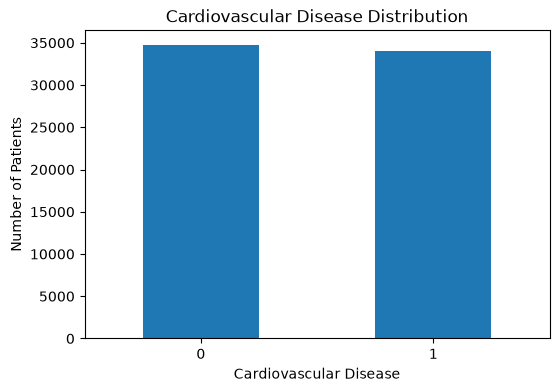

In [294]:
plt.figure(figsize=(6, 4))

df["cardio"].value_counts().sort_index().plot(kind="bar")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

In [295]:
df["age_years"].describe()

count    68741.000000
mean        53.290983
std          6.757190
min         29.563313
25%         48.342231
50%         53.938398
75%         58.381930
max         64.922656
Name: age_years, dtype: float64

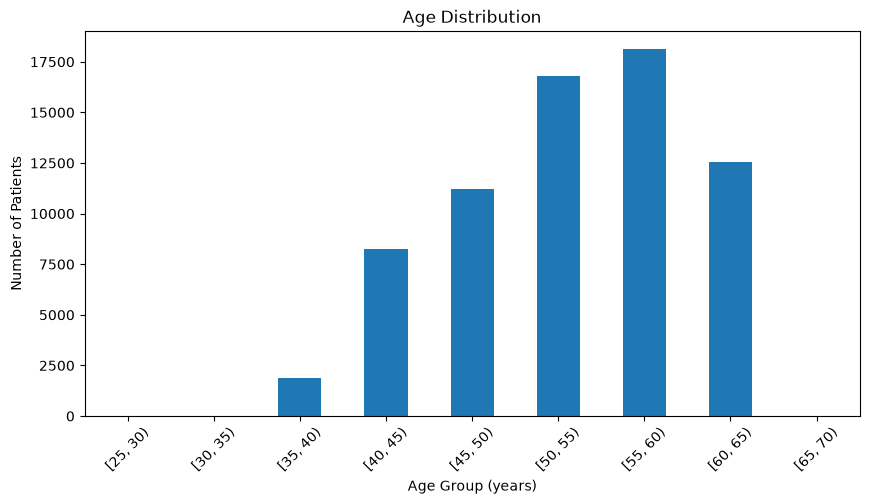

In [296]:
age_groups = pd.cut(
    df["age_years"],
    bins=[25, 30, 35, 40, 45, 50, 55, 60, 65, 70],
    right=False
)

age_counts = age_groups.value_counts().sort_index()

plt.figure(figsize=(10, 5))

age_counts.plot(kind="bar")

plt.title("Age Distribution")
plt.xlabel("Age Group (years)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

In [297]:
age_counts

age_years
[25, 30)        3
[30, 35)        1
[35, 40)     1858
[40, 45)     8251
[45, 50)    11207
[50, 55)    16785
[55, 60)    18111
[60, 65)    12525
[65, 70)        0
Name: count, dtype: int64

In [298]:
df.groupby("cardio")["age_years"].mean()

cardio
0    51.688260
1    54.926541
Name: age_years, dtype: float64

### Age Distribution

The age distribution shows that most observations are concentrated between 50 and 64 years.

The largest age group is 55–59 years, followed by 50–54 and 60–64 years.

When comparing the average age between the two target classes, patients without cardiovascular disease have an average age of approximately 51.69 years, while patients with cardiovascular disease have an average age of approximately 54.93 years.

This indicates that age may have a relationship with cardiovascular disease in this dataset, with the disease class having a higher average age. 

In [299]:
gender_cardio = pd.crosstab(df["gender"], df["cardio"])
gender_cardio

gender_cardio_pct = pd.crosstab(
    df["gender"],
    df["cardio"],
    normalize="index"
).mul(100).round(2)

gender_cardio_pct




cardio,0,1
gender,,
1,50.78,49.22
2,50.01,49.99


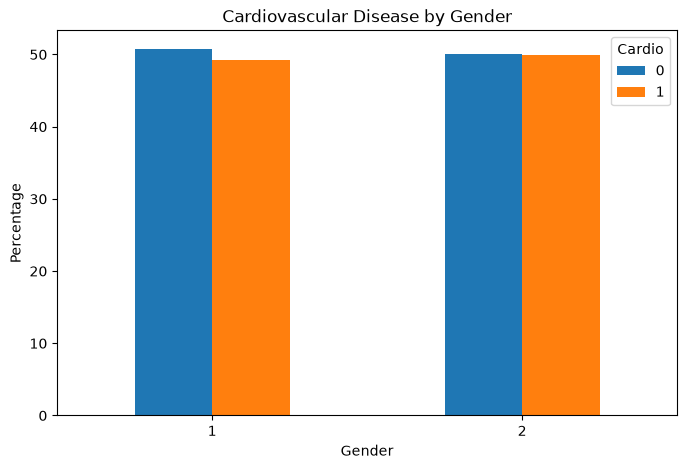

In [300]:
gender_cardio_pct.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Cardio")
plt.show()

## 6.3 Gender and Cardiovascular Disease

The distribution of cardiovascular disease is very similar across the two gender categories.

- Gender 1: 49.22% of observations belong to the cardiovascular disease class, while 50.78% belong to the non-disease class.
- Gender 2: 49.99% of observations belong to the cardiovascular disease class, while 50.01% belong to the non-disease class.

The differences between the two gender groups are very small, suggesting that gender alone does not show a strong relationship with the target variable in this dataset.

In [301]:
height_cardio = df.groupby("cardio")["height"].mean()
height_cardio

cardio
0    164.489156
1    164.297749
Name: height, dtype: float64

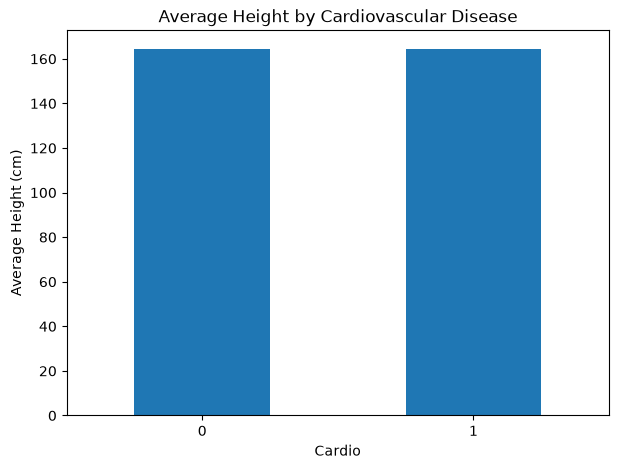

In [302]:
height_cardio = df.groupby("cardio")["height"].mean()

plt.figure(figsize=(7, 5))

height_cardio.plot(kind="bar")

plt.title("Average Height by Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Average Height (cm)")
plt.xticks(rotation=0)

plt.show()



### Height and Cardiovascular Disease

The average height is very similar between the two cardiovascular disease classes.

* Cardio 0: 164.49 cm
* Cardio 1: 164.30 cm

The difference in average height is approximately 0.19 cm, indicating that height does not show a noticeable difference between the two target classes in this dataset.


In [303]:
weight_cardio = df.groupby("cardio")["weight"].mean()

weight_cardio

cardio
0    71.576892
1    76.721880
Name: weight, dtype: float64

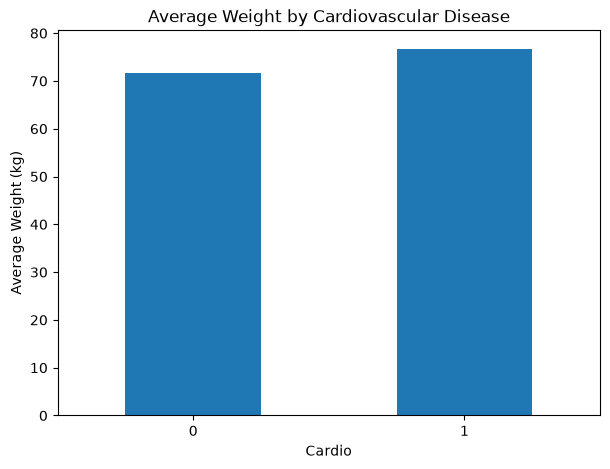

In [304]:
plt.figure(figsize=(7, 5))

weight_cardio.plot(kind="bar")

plt.title("Average Weight by Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Average Weight (kg)")
plt.xticks(rotation=0)

plt.show()


###  Weight and Cardiovascular Disease

The average weight differs between the two cardiovascular disease classes.

- Cardio 0: 71.58 kg
- Cardio 1: 76.72 kg

Patients with cardiovascular disease have a higher average weight by approximately 5.14 kg compared with patients without cardiovascular disease.

This suggests that weight may have a relationship with cardiovascular disease in this dataset.

In [305]:
ap_hi_cardio = df.groupby("cardio")["ap_hi"].mean()

ap_hi_cardio

cardio
0    119.563063
1    133.815208
Name: ap_hi, dtype: float64

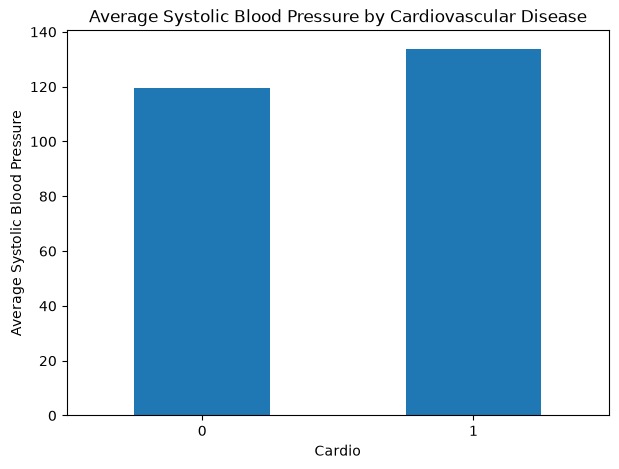

In [306]:
plt.figure(figsize=(7, 5))

ap_hi_cardio.plot(kind="bar")

plt.title("Average Systolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Average Systolic Blood Pressure")
plt.xticks(rotation=0)

plt.show()


###  Systolic Blood Pressure and Cardiovascular Disease

The average systolic blood pressure differs noticeably between the two cardiovascular disease classes.

- Cardio 0: 119.56 mmHg
- Cardio 1: 133.82 mmHg

Patients with cardiovascular disease have a higher average systolic blood pressure by approximately 14.25 mmHg compared with patients without cardiovascular disease.

This indicates that systolic blood pressure may have a strong relationship with cardiovascular disease in this dataset.

In [307]:
ap_lo_cardio = df.groupby("cardio")["ap_lo"].mean()

ap_lo_cardio

cardio
0    78.173623
1    84.657075
Name: ap_lo, dtype: float64

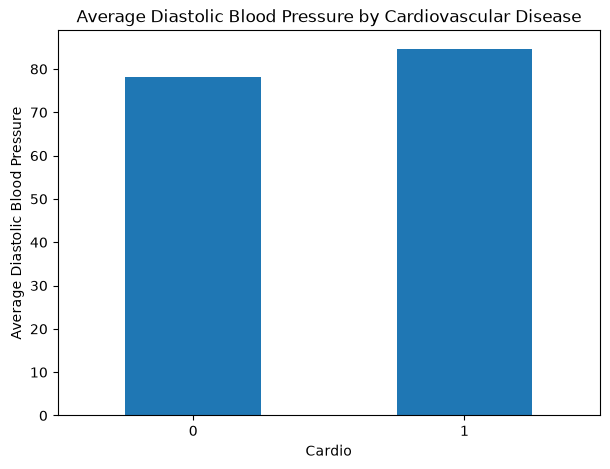

In [308]:
plt.figure(figsize=(7, 5))

ap_lo_cardio.plot(kind="bar")

plt.title("Average Diastolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Average Diastolic Blood Pressure")
plt.xticks(rotation=0)

plt.show()

###  Diastolic Blood Pressure and Cardiovascular Disease

The average diastolic blood pressure differs between the two cardiovascular disease classes.

- Cardio 0: 78.17 mmHg
- Cardio 1: 84.66 mmHg

Patients with cardiovascular disease have a higher average diastolic blood pressure by approximately 6.48 mmHg compared with patients without cardiovascular disease.

This indicates that diastolic blood pressure may also have a relationship with cardiovascular disease in this dataset.


In [309]:
cholesterol_cardio = pd.crosstab(
    df["cholesterol"],
    df["cardio"],
    normalize="index"
).mul(100).round(2)

cholesterol_cardio

cardio,0,1
cholesterol,,
1,56.44,43.56
2,40.36,59.64
3,23.71,76.29


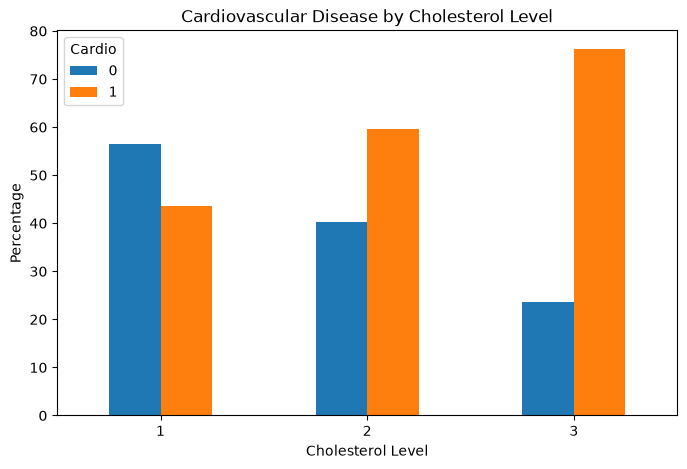

In [310]:
cholesterol_cardio.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Cardio")

plt.show()

### Cholesterol and Cardiovascular Disease

The distribution of cardiovascular disease varies considerably across cholesterol levels.

- Cholesterol 1: 43.56% of patients have cardiovascular disease.
- Cholesterol 2: 59.64% of patients have cardiovascular disease.
- Cholesterol 3: 76.29% of patients have cardiovascular disease.

The percentage of patients with cardiovascular disease increases as the cholesterol level increases.

This suggests a strong relationship between cholesterol level and cardiovascular disease in this dataset.

In [311]:
gluc_cardio = pd.crosstab(
    df["gluc"],
    df["cardio"],
    normalize="index"
).mul(100).round(2)


gluc_cardio

cardio,0,1
gluc,,
1,52.43,47.57
2,41.13,58.87
3,38.14,61.86


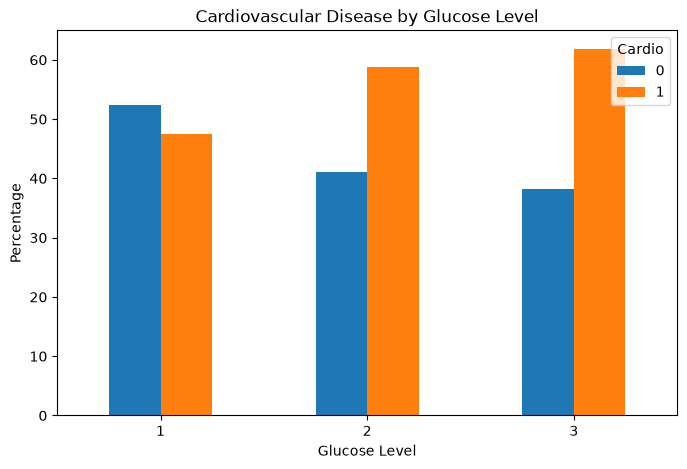

In [312]:
gluc_cardio.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Glucose Level")
plt.xlabel("Glucose Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Cardio")

plt.show()

### Glucose and Cardiovascular Disease

The distribution of cardiovascular disease varies across the glucose levels.

- Glucose 1: 47.57% of patients have cardiovascular disease.
- Glucose 2: 58.87% of patients have cardiovascular disease.
- Glucose 3: 61.86% of patients have cardiovascular disease.

The percentage of patients with cardiovascular disease increases as the glucose level increases.

This suggests that glucose level may have a relationship with cardiovascular disease in this dataset.

In [313]:
smoke_cardio = pd.crosstab(
    df["smoke"],
    df["cardio"],
    normalize="index"
).mul(100).round(2)


smoke_cardio

cardio,0,1
smoke,,
0,50.25,49.75
1,53.13,46.87


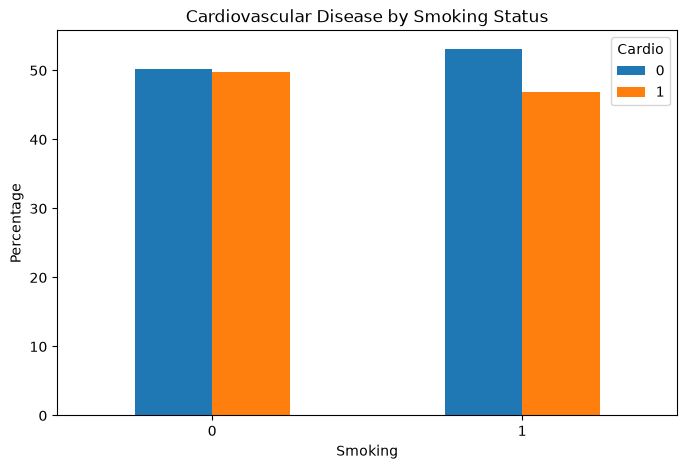

In [314]:
smoke_cardio.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Smoking Status")
plt.xlabel("Smoking")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Cardio")

plt.show()

### Smoking and Cardiovascular Disease

The distribution of cardiovascular disease is very similar between smokers and non-smokers.

- Non-smokers: 49.75% of patients have cardiovascular disease.
- Smokers: 46.87% of patients have cardiovascular disease.

The difference between the two groups is approximately 2.88 percentage points, indicating that smoking status alone does not show a strong relationship with cardiovascular disease in this dataset.



In [315]:
alco_cardio = pd.crosstab(
    df["alco"],
    df["cardio"],
    normalize="index"
).mul(100).round(2)


alco_cardio

cardio,0,1
alco,,
0,50.41,49.59
1,52.20,47.80


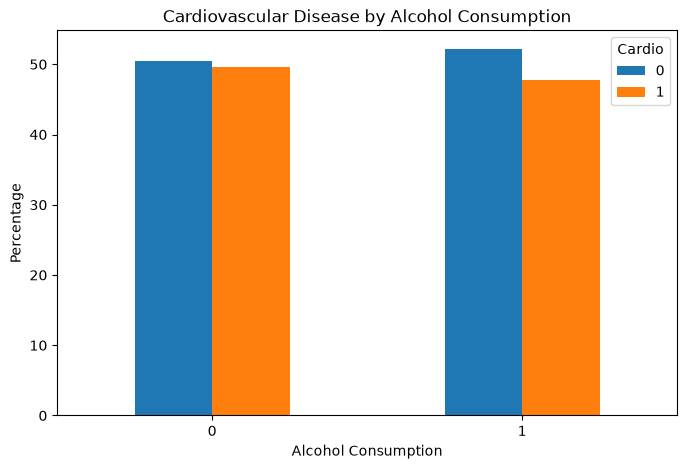

In [316]:
alco_cardio.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Alcohol Consumption")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Cardio")

plt.show()

### Alcohol Consumption and Cardiovascular Disease

The distribution of cardiovascular disease is very similar between patients who consume alcohol and those who do not.

- Non-alcohol consumers: 49.59% of patients have cardiovascular disease.
- Alcohol consumers: 47.80% of patients have cardiovascular disease.

The difference between the two groups is approximately 1.79 percentage points, indicating that alcohol consumption alone does not show a strong relationship with cardiovascular disease in this dataset.

In [317]:
active_cardio = pd.crosstab(
    df["active"],
    df["cardio"],
    normalize="index"
).mul(100).round(2)


active_cardio

cardio,0,1
active,,
0,46.73,53.27
1,51.43,48.57


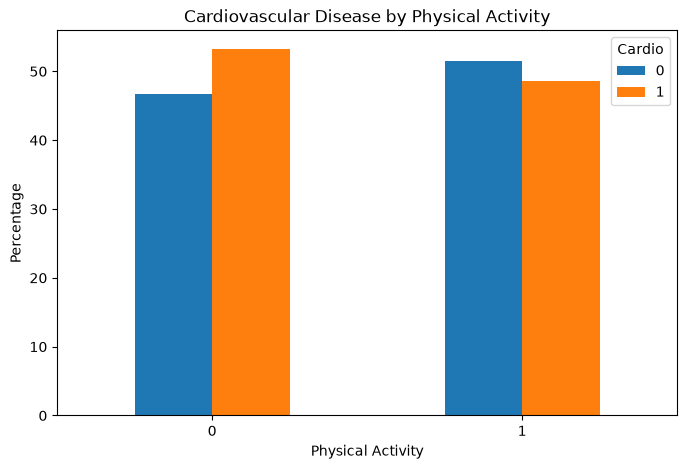

In [318]:
active_cardio.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Physical Activity")
plt.xlabel("Physical Activity")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Cardio")

plt.show()


### Physical Activity and Cardiovascular Disease

The distribution of cardiovascular disease differs between active and inactive patients.

- Inactive patients: 53.27% have cardiovascular disease.
- Active patients: 48.57% have cardiovascular disease.

The difference between the two groups is approximately 4.70 percentage points, indicating that physical activity may have a relationship with cardiovascular disease in this dataset.

In [319]:
numeric_cols = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cardio"
]

correlation = df[numeric_cols].corr()

correlation

,age_years,height,weight,ap_hi,ap_lo,cardio
age_years,1.000000,-0.084474,0.055054,0.208671,0.152709,0.239607
height,-0.084474,1.000000,0.301977,0.018120,0.035663,-0.011997
weight,0.055054,0.301977,1.000000,0.269214,0.249273,0.179802
ap_hi,0.208671,0.018120,0.269214,1.000000,0.697910,0.425064
ap_lo,0.152709,0.035663,0.249273,0.697910,1.000000,0.334990
cardio,0.239607,-0.011997,0.179802,0.425064,0.334990,1.000000


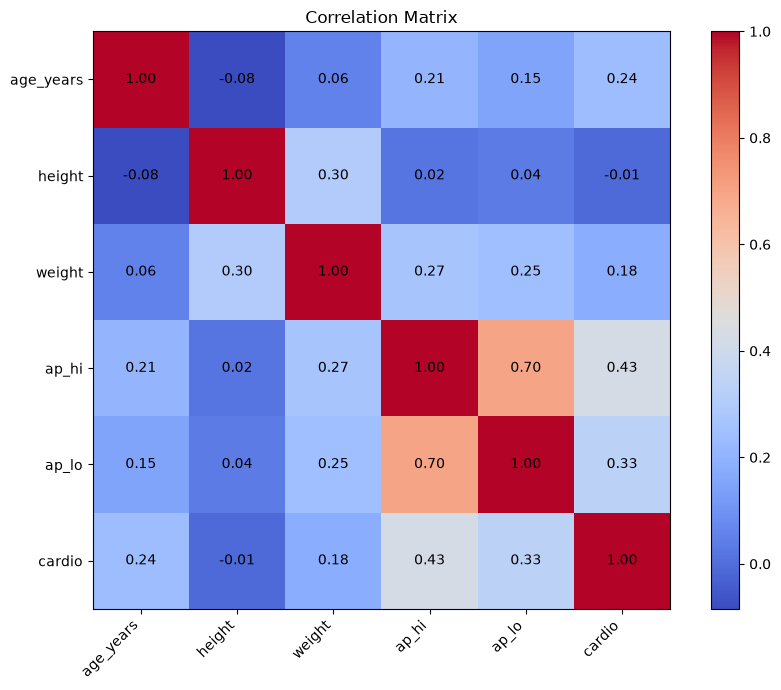

In [320]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

### Correlation Analysis

The correlation matrix was used to examine the linear relationships between the numerical features and cardiovascular disease.

The strongest positive correlation with cardiovascular disease is observed for systolic blood pressure ap_hi, with a correlation coefficient of 0.425.

Diastolic blood pressure ap_lo also shows a positive correlation with cardiovascular disease, with a coefficient of 0.335.

Age_years has a positive correlation of 0.240, while weight has a weaker positive correlation of 0.180.

Height has a correlation coefficient of -0.012 with cardiovascular disease, indicating an almost negligible linear relationship.

A relatively strong correlation of 0.698 is observed between systolic and diastolic blood pressure, which is expected because both variables represent related blood pressure measurements.

Overall, blood pressure, age, and weight show more noticeable linear relationships with cardiovascular disease compared with height.


# Model Preparation

The dataset was prepared for the modeling stage using the cleaned features and the target variable cardio.

In [321]:
X = df.drop(["cardio" , "id"] , axis = 1)
y = df["cardio"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (68741, 11)
Target shape: (68741,)


In [322]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (54992, 11)
Test set: (13749, 11)


In [323]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [324]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_lr.fit(X_train, y_train)

y_pred_lr = baseline_lr.predict(X_test)



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Baseline Precision:", precision_score(y_test, y_pred_lr))
print("Baseline Recall:", recall_score(y_test, y_pred_lr))
print("Baseline F1:", f1_score(y_test, y_pred_lr))

Baseline Accuracy: 0.7305985889882901
Baseline Precision: 0.759324301722696
Baseline Recall: 0.6671565025716385
Baseline F1: 0.7102628285356696


In [325]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7156884137028148
Random Forest Precision: 0.7189957652752571
Random Forest Recall: 0.6986039676708302
Random Forest F1: 0.708653201162704


In [326]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))
print("Decision Tree F1:", f1_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6321186995417849
Decision Tree Precision: 0.6274996350897679
Decision Tree Recall: 0.6317413666421748
Decision Tree F1: 0.6296133567662566


In [327]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print("KNN F1:", f1_score(y_test, y_pred_knn))

KNN Accuracy: 0.6951778311149902
KNN Precision: 0.6982104943888383
KNN Recall: 0.6765613519470978
KNN F1: 0.6872154638405851


In [328]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.730599,0.759324,0.667157,0.710263
1,Random Forest,0.715688,0.718996,0.698604,0.708653
2,Decision Tree,0.632119,0.627500,0.631741,0.629613
3,KNN,0.695178,0.698210,0.676561,0.687215


In [329]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    baseline_lr,
    lr_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best Parameters: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Best CV F1: 0.7086314473872932


In [330]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    rf_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.7155467530533081


In [331]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV F1:", grid_dt.best_score_)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV F1: 0.7103634523112747


In [332]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [333]:
final_rf = RandomForestClassifier(
    **grid_rf.best_params_,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_final, y_train_final)

y_val_prob = final_rf.predict_proba(X_val)[:, 1]

In [334]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_val, y_val_pred):.4f} | "
        f"Recall: {recall_score(y_val, y_val_pred):.4f} | "
        f"F1: {f1_score(y_val, y_val_pred):.4f}"
    )

Threshold: 0.30 | Precision: 0.6239 | Recall: 0.8723 | F1: 0.7275
Threshold: 0.35 | Precision: 0.6522 | Recall: 0.8316 | F1: 0.7310
Threshold: 0.40 | Precision: 0.6817 | Recall: 0.7809 | F1: 0.7279
Threshold: 0.45 | Precision: 0.7159 | Recall: 0.7342 | F1: 0.7249
Threshold: 0.50 | Precision: 0.7400 | Recall: 0.6886 | F1: 0.7134
Threshold: 0.55 | Precision: 0.7639 | Recall: 0.6453 | F1: 0.6996
Threshold: 0.60 | Precision: 0.7855 | Recall: 0.6040 | F1: 0.6829


In [335]:
final_threshold = 0.35

y_test_prob = final_rf.predict_proba(X_test)[:, 1]

y_test_final = (
    y_test_prob >= final_threshold
).astype(int)

print("Final Accuracy:", accuracy_score(y_test, y_test_final))
print("Final Precision:", precision_score(y_test, y_test_final))
print("Final Recall:", recall_score(y_test, y_test_final))
print("Final F1:", f1_score(y_test, y_test_final))

Final Accuracy: 0.7065968434067932
Final Precision: 0.6628658751616316
Final Recall: 0.8286554004408523
Final F1: 0.7365464994775339


[[4076 2868]
 [1166 5639]]


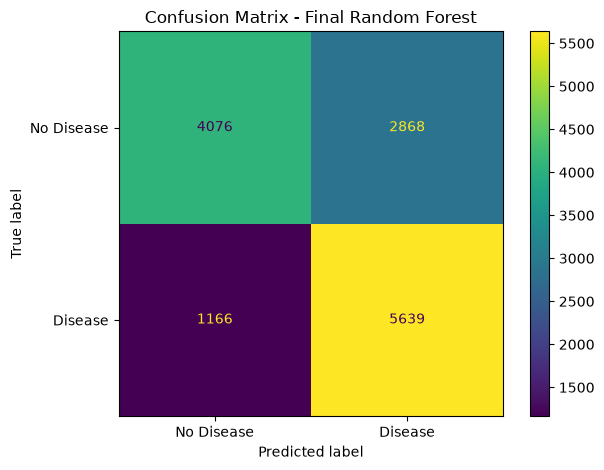

In [336]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_final)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix - Final Random Forest")
plt.tight_layout()
plt.show()

In [337]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_final,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ]
    )
)

                           precision    recall  f1-score   support

No Cardiovascular Disease       0.78      0.59      0.67      6944
   Cardiovascular Disease       0.66      0.83      0.74      6805

                 accuracy                           0.71     13749
                macro avg       0.72      0.71      0.70     13749
             weighted avg       0.72      0.71      0.70     13749



In [338]:
feature_importance = pd.Series(
    final_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

ap_hi          0.266715
age_years      0.234640
weight         0.137118
ap_lo          0.120570
height         0.116153
cholesterol    0.054531
gluc           0.020442
active         0.015143
gender         0.015101
smoke          0.010412
alco           0.009175
dtype: float64


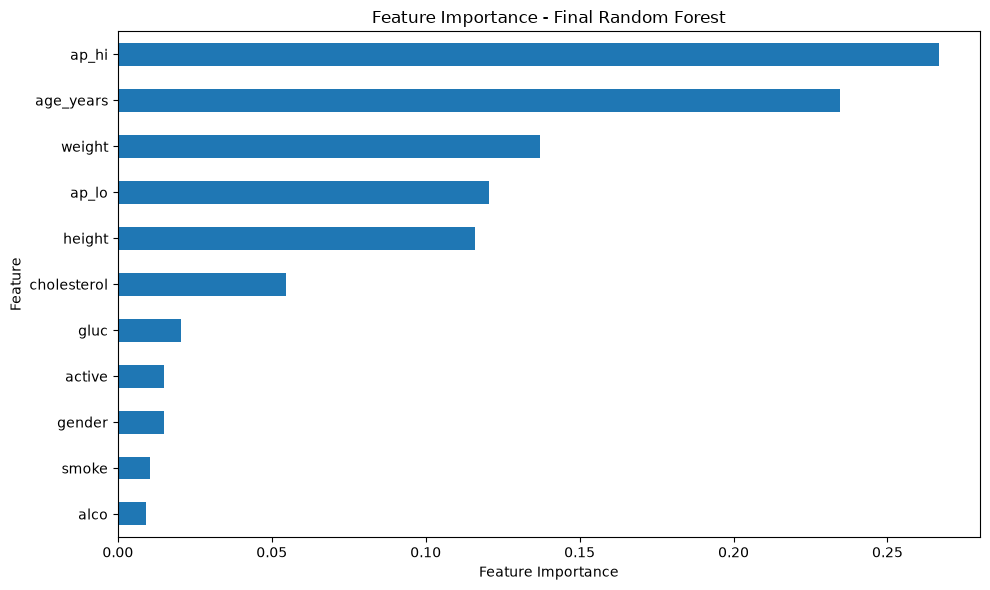

In [344]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final Random Forest")

plt.tight_layout()
plt.show()

In [345]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

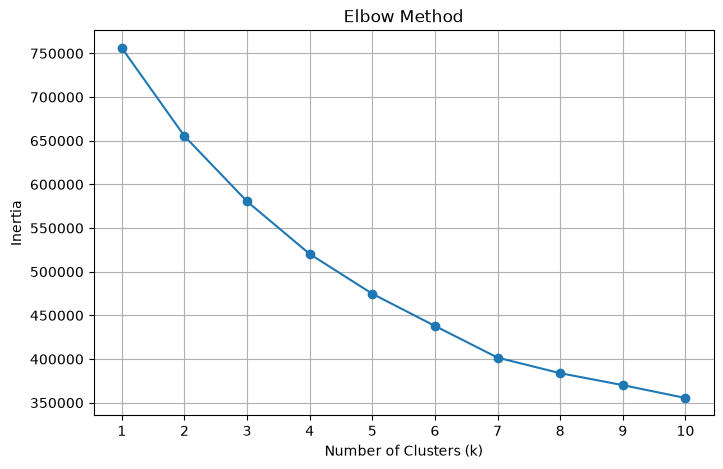

In [346]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [347]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    
    print(f"k={k} | Silhouette Score={score:.4f}")

k=2 | Silhouette Score=0.1785
k=3 | Silhouette Score=0.1884
k=4 | Silhouette Score=0.1842
k=5 | Silhouette Score=0.1811
k=6 | Silhouette Score=0.1924
k=7 | Silhouette Score=0.2016
k=8 | Silhouette Score=0.1587
k=9 | Silhouette Score=0.1579
k=10 | Silhouette Score=0.1680


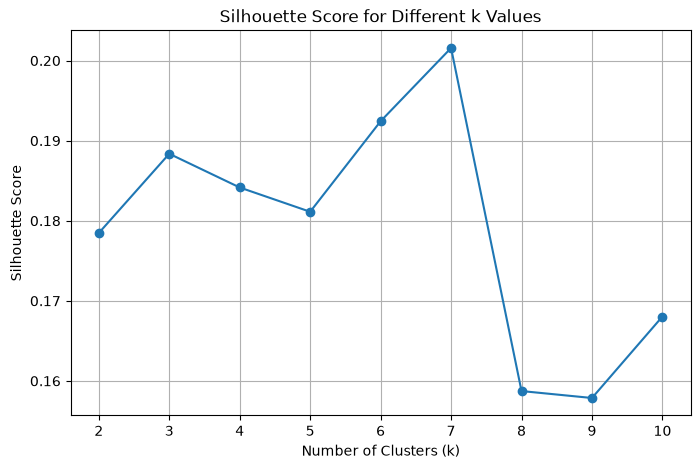

In [351]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")

plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [352]:
best_k = 7

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

In [353]:
print(df["cluster"].value_counts().sort_index())

cluster
0    22140
1    10342
2     3645
3     5658
4     4074
5    11799
6    11083
Name: count, dtype: int64


In [354]:
cluster_profile = df.groupby("cluster")[cluster_features].mean()

cluster_profile.round(2)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
cluster,,,,,,,,,,,
0,52.11,1.01,161.38,68.42,117.31,76.45,1.14,1.05,0.00,0.00,1.00
1,53.04,1.31,164.22,72.67,123.53,79.84,1.20,1.07,0.00,0.00,0.00
2,52.41,1.70,167.77,78.15,128.77,83.04,1.45,1.23,0.50,1.00,0.84
3,55.83,1.25,163.28,77.46,129.96,82.89,2.41,2.85,0.02,0.01,0.81
4,52.27,1.86,169.31,76.98,127.31,81.67,1.33,1.16,1.00,0.00,0.83
5,52.73,1.98,170.84,76.83,124.52,80.55,1.18,1.06,0.00,0.00,0.99
6,55.86,1.13,161.36,79.90,147.64,92.14,1.60,1.10,0.00,0.00,0.93
